In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import japanize_matplotlib 

from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import KFold

from scipy.signal import savgol_filter
from scipy.spatial import ConvexHull
from scipy import sparse
from scipy.sparse.linalg import spsolve
from sklearn.base import BaseEstimator, TransformerMixin

pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

# 関数を定義

In [2]:
# =========================
# 外れ値除去
# =========================
def remove_outliers(spectra, prop, sigma_1=3.0, sigma_2=3.0):
    spec_mean = spectra.mean(axis=1)
    mu, std = spec_mean.mean(), spec_mean.std()
    spec_mask = (spec_mean >= mu - sigma_1 * std) & (spec_mean <= mu + sigma_1 * std)

    if isinstance(prop, pd.Series):
        prop = prop.to_frame("prop")

    prop_mean = prop.mean(axis=1)
    mu2, std2 = prop_mean.mean(), prop_mean.std()
    prop_mask = (prop_mean >= mu2 - sigma_2 * std2) & (prop_mean <= mu2 + sigma_2 * std2)

    mask = spec_mask & prop_mask

    return spectra.loc[mask], prop.loc[mask]


# =========================
# Savitzky-Golay smoothing
# =========================
def savgol_smoothing(spectra, window_length=11, polyorder=2):
    return spectra.apply(
        lambda row: savgol_filter(row.values, window_length, polyorder),
        axis=1, result_type='broadcast'
    )


# =========================
# MSC
# =========================
def msc_transform(spectra):
    reference = spectra.mean(axis=0).values

    def _msc(row):
        X = np.vstack([reference, np.ones_like(reference)]).T
        coef, _, _, _ = np.linalg.lstsq(X, row.values, rcond=None)
        a, b = coef
        return (row.values - b) / a

    corrected = spectra.apply(_msc, axis=1, result_type='broadcast')
    return pd.DataFrame(corrected, index=spectra.index, columns=spectra.columns)


# =========================
# ALS baseline
# =========================
def _als_one(y, lam=1e5, p=0.01, n_iter=10):
    L = len(y)
    D = sparse.diags([1, -2, 1], [0, 1, 2], shape=(L-2, L))
    w = np.ones(L)

    for _ in range(n_iter):
        W = sparse.diags(w, 0)
        Z = W + lam * D.T @ D
        z = spsolve(Z, w * y)
        w = p * (y > z) + (1 - p) * (y <= z)

    return z


def als_baseline_correction(spectra, lam=1e5, p=0.01, n_iter=10):
    baseline = np.zeros_like(spectra.values)

    for i, row in enumerate(spectra.values):
        baseline[i, :] = _als_one(row, lam, p, n_iter)

    baseline_df = pd.DataFrame(baseline, index=spectra.index, columns=spectra.columns)
    corrected = spectra - baseline_df

    return corrected, baseline_df


# =========================
# PLS CV
# =========================
def pls_regression_cv(X, y, n_splits=5, n_components=2, random_state=117):

    cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    oof_pred = np.zeros(len(y))

    for tr, te in cv.split(X):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr = y.iloc[tr]

        pls = PLSRegression(n_components=n_components)
        pls.fit(X_tr, y_tr)

        oof_pred[te] = pls.predict(X_te).ravel()

    rmse = np.sqrt(mean_squared_error(y, oof_pred))
    r2 = r2_score(y, oof_pred)

    return {
        "oof_pred": oof_pred,
        "rmse": rmse,
        "r2": r2,
    }


# =========================
# 評価プロット
# =========================
def evaluate_and_plot(y_true, y_pred):
    print("R2:", r2_score(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("MAE:", mean_absolute_error(y_true, y_pred))

    plt.figure(figsize=(4,4))
    plt.scatter(y_true, y_pred, c="blue", edgecolors='k', alpha=0.7)

    y_min = min(np.max(y_true), np.min(y_pred))
    y_max = max(np.max(y_true), np.max(y_pred))
    buffer = (y_max - y_min) * 0.05
    
    lower = max(y_min - buffer, 0)
    upper = y_max + buffer
    
    lower = round(lower, 2)
    upper = round(upper, 2)
    
    # 参考線（y=X）
    plt.plot([lower, upper], [lower, upper], 'k-', linewidth=1)

    plt.xlim(lower, upper)
    plt.ylim(lower, upper)
    
    ticks = np.round(np.linspace(lower, upper, 6), 1)
    plt.xticks(ticks)
    plt.yticks(ticks)
    
    plt.xlabel("Actual_y")
    plt.ylabel("Predicted_y")
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()


# =========================
# スペクトルプロット
# =========================
def plot_spectra(wave, spec):
    plt.figure(figsize=(6,4))
    plt.plot(wave, spec.T)
    plt.xlabel("Wavelength")
    plt.ylabel("Absorbance")
    plt.title("Spectra")
    plt.show()

In [3]:
def derivative (spectra, order=1, window_length=15, polyorder=2):
    derive = spectra.apply(
        lambda row: savgol_filter(row.values, 
                                  window_length=window_length, 
                                  polyorder=polyorder, 
                                  delta=1.0, 
                                  deriv=order
                                  ),
        axis=1, result_type='broadcast')
    return pd.DataFrame(derive, index=spectra.index, columns=spectra.columns)

# SNV
def snv_transform(spectra):
    def _snv(row):
        mean = row.mean()
        std = row.std(ddof=0)
        return (row - mean) / std

    corrected = spectra.apply(_snv, axis=1, result_type='broadcast')
    return pd.DataFrame(corrected, index=spectra.index, columns=spectra.columns)

# 分析

In [6]:
train_orig = pd.read_csv(r"C:\Users\takit\Documents\data\signate_NIR\data\train.csv", encoding="cp932")
test = pd.read_csv(r"C:\Users\takit\Documents\data\signate_NIR\data\test.csv", encoding="cp932")

In [7]:
exclude_species = [
    #"チェリー", 
    "ベイスギ"
    ]
train = train_orig[~train_orig["樹種"].isin(exclude_species)].copy()

y = train["含水率"]

In [39]:
kou_1 = [
    #'イチョウ', 
    #'ウエンジ', 
    #'ウォールナット', 
    'クリ', 
    #'チェリー', 
    'トチ',
    #'ナラ', 
    #'ホワイトオーク'
]

kou_2 = [
    #'イチョウ', 
    #'ウエンジ', 
    #'ウォールナット', 
    #'クリ', 
    #'チェリー', 
    #'トチ',
    'ナラ', 
    'ホワイトオーク'
]

kou_3 = [
    #'イチョウ', 
    'ウエンジ', 
    'ウォールナット', 
    #'クリ', 
    #'チェリー', 
    #'トチ',
    #'ナラ', 
    #'ホワイトオーク'
] 

shin = [
    'スプルース', 
    'ヒノキ', 
    #'ベイスギ', 
    '米ヒバ', 
    'ベイマツ', 
]

train_shin = train.loc[train["樹種"].isin(shin)]
train_kou_1 = train.loc[train["樹種"].isin(kou_1)]
train_kou_2 = train.loc[train["樹種"].isin(kou_2)]
train_kou_3 = train.loc[train["樹種"].isin(kou_3)]

In [40]:
shin_idx = train_shin.index
kou_1_idx = train_kou_1.index
kou_2_idx = train_kou_2.index
kou_3_idx = train_kou_3.index

In [41]:
spectra_shin = train_shin.iloc[:, 4:]
spectra_kou_1 = train_kou_1.iloc[:, 4:]
spectra_kou_2 = train_kou_2.iloc[:, 4:]
spectra_kou_3 = train_kou_3.iloc[:, 4:]

spectra_shin.columns = spectra_shin.columns.astype(float)
spectra_kou_1.columns = spectra_kou_1.columns.astype(float)
spectra_kou_2.columns = spectra_kou_2.columns.astype(float)
spectra_kou_3.columns = spectra_kou_3.columns.astype(float)

y_shin = train_shin["含水率"]
y_kou_1 = train_kou_1["含水率"]
y_kou_2 = train_kou_2["含水率"]
y_kou_3 = train_kou_3["含水率"]

# --- 波長範囲制限 ---
spectra_shin = spectra_shin.loc[:, (spectra_shin.columns >= 3000) & (spectra_shin.columns <= 10000)]
spectra_kou_1 = spectra_kou_1.loc[:, (spectra_kou_1.columns >= 3000) & (spectra_kou_1.columns <= 10000)]
spectra_kou_2 = spectra_kou_2.loc[:, (spectra_kou_2.columns >= 3000) & (spectra_kou_2.columns <= 10000)]
spectra_kou_3 = spectra_kou_3.loc[:, (spectra_kou_3.columns >= 3000) & (spectra_kou_3.columns <= 10000)]

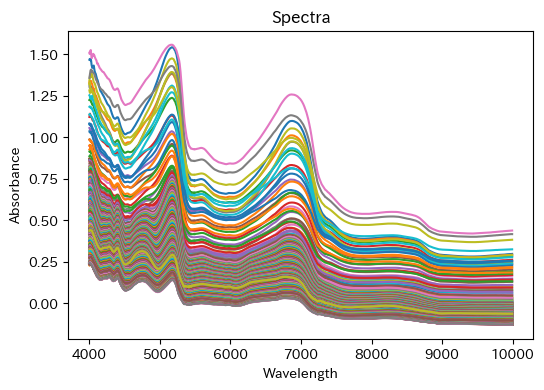

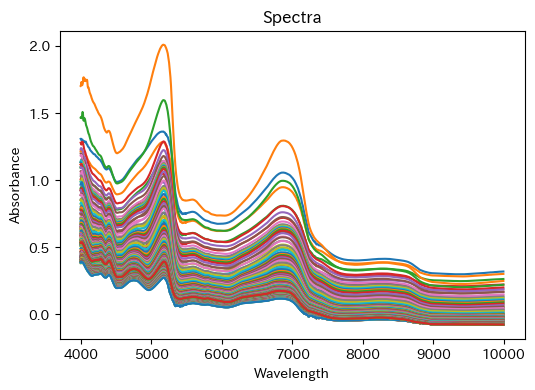

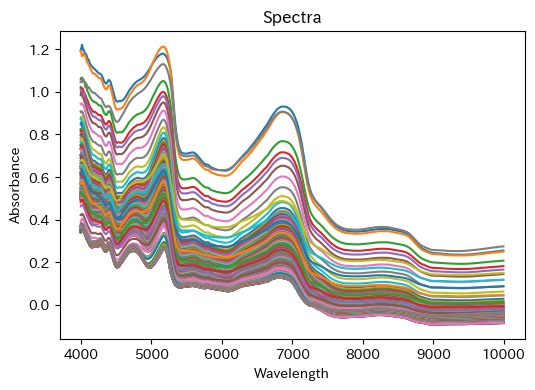

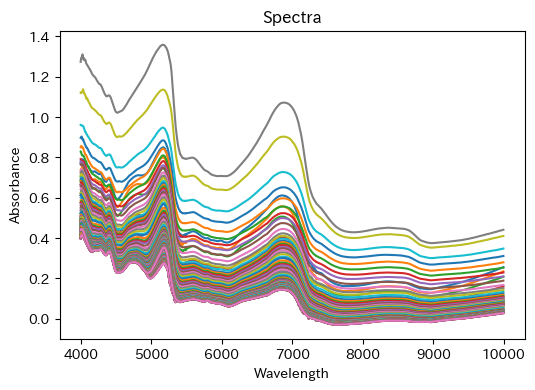

In [42]:
plot_spectra(spectra_shin.columns, spectra_shin)
plot_spectra(spectra_kou_1.columns, spectra_kou_1)
plot_spectra(spectra_kou_2.columns, spectra_kou_2)
plot_spectra(spectra_kou_3.columns, spectra_kou_3)

In [46]:
# --- outliers除去 ---
#spectra_clean, y_clean = remove_outliers(spectra, y)

#print("削除前サンプル数:", len(spectra))
#print("削除後サンプル数:", len(spectra_clean))

#plot_spectra(spectra_clean.columns, spectra_clean)

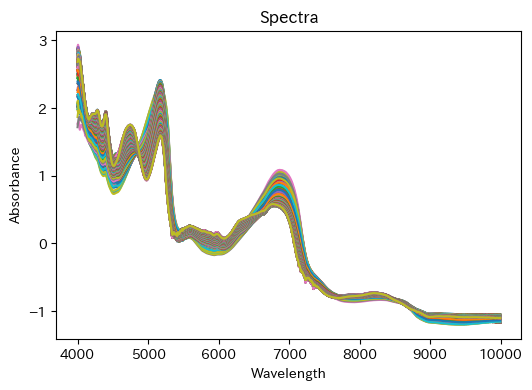

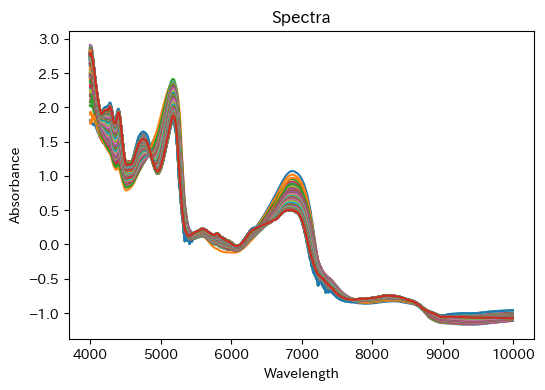

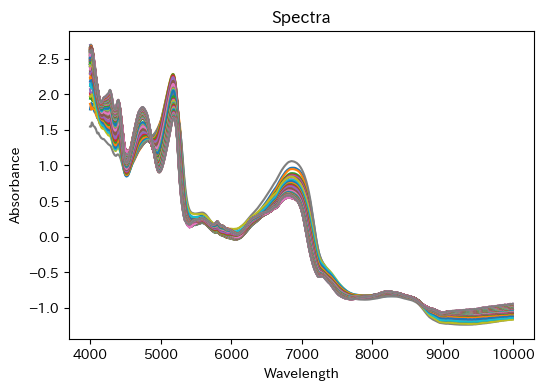

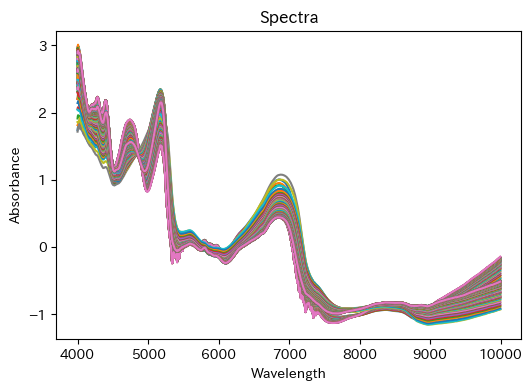

In [43]:
# スムージング & MSC
#spectra_smooth = savgol_smoothing(spectra_clean, window_length=17, polyorder=2)
spectra_shin_snv = snv_transform(spectra_shin)
spectra_kou_1_snv = snv_transform(spectra_kou_1)
spectra_kou_2_snv = snv_transform(spectra_kou_2)
spectra_kou_3_snv = snv_transform(spectra_kou_3)

plot_spectra(spectra_shin_snv.columns, spectra_shin_snv)
plot_spectra(spectra_kou_1_snv.columns, spectra_kou_1_snv)
plot_spectra(spectra_kou_2_snv.columns, spectra_kou_2_snv)
plot_spectra(spectra_kou_3_snv.columns, spectra_kou_3_snv)

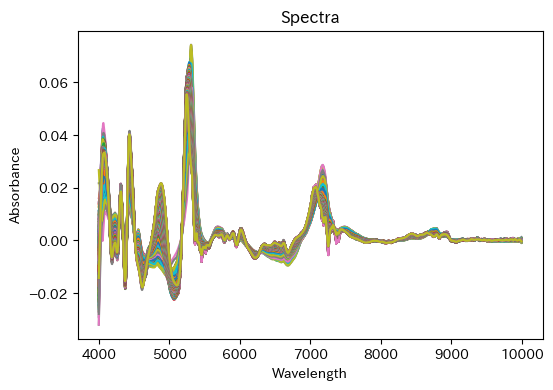

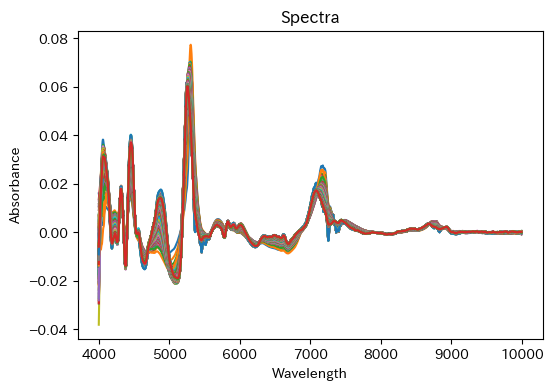

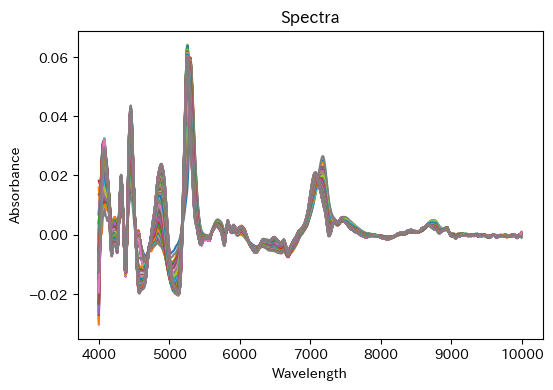

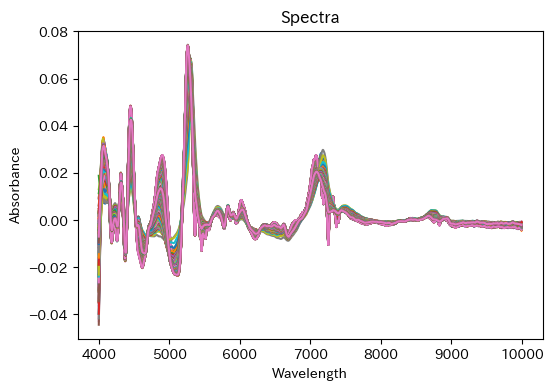

In [44]:
spectra_shin_deri = derivative(spectra_shin_snv, order=1, window_length=15, polyorder=2)
plot_spectra(spectra_shin_deri.columns, spectra_shin_deri)

spectra_kou_1_deri = derivative(spectra_kou_1_snv, order=1, window_length=15, polyorder=2)
plot_spectra(spectra_kou_1_deri.columns, spectra_kou_1_deri)

spectra_kou_2_deri = derivative(spectra_kou_2_snv, order=1, window_length=15, polyorder=2)
plot_spectra(spectra_kou_2_deri.columns, spectra_kou_2_deri)

spectra_kou_3_deri = derivative(spectra_kou_3_snv, order=1, window_length=15, polyorder=2)
plot_spectra(spectra_kou_3_deri.columns, spectra_kou_3_deri)

R2: 0.9751300829071579
RMSE: 7.520440163796246
MAE: 5.803139589218452


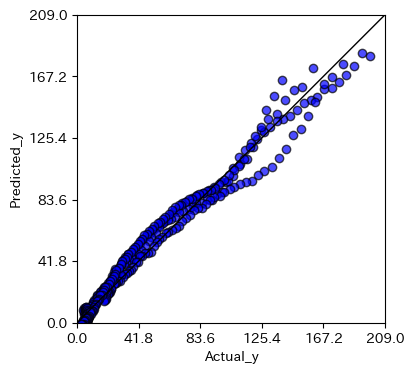

In [45]:
# --- PLS ---
result_shin_deri = pls_regression_cv(
    X = spectra_shin_deri, 
    y = y_shin, 
    n_splits=5,
    n_components=2,
    random_state=117
    )

evaluate_and_plot(y_shin, result_shin_deri["oof_pred"])

R2: 0.9639348870010523
RMSE: 7.693951169000979
MAE: 5.745084447792179


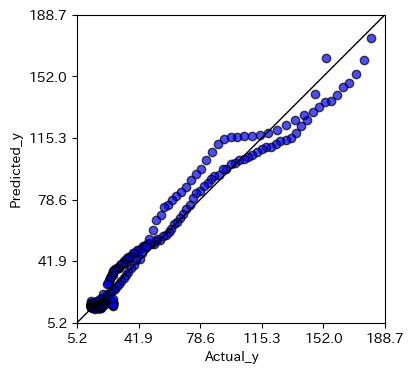

In [46]:
result_kou_1_deri = pls_regression_cv(
    X = spectra_kou_1_deri, 
    y = y_kou_1, 
    n_splits=5,
    n_components=2,
    random_state=117
    )

evaluate_and_plot(y_kou_1, result_kou_1_deri["oof_pred"])

R2: 0.9295977641183001
RMSE: 6.425514907308251
MAE: 4.229830890390601


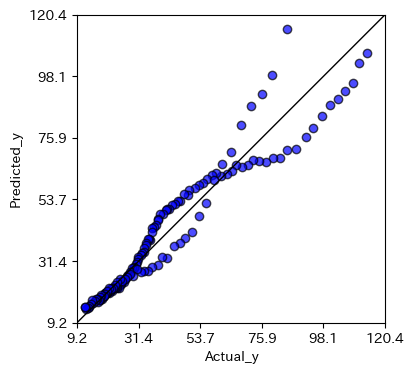

In [47]:
result_kou_2_deri = pls_regression_cv(
    X = spectra_kou_2_deri, 
    y = y_kou_2, 
    n_splits=5,
    n_components=2,
    random_state=117
    )

evaluate_and_plot(y_kou_2, result_kou_2_deri["oof_pred"])


R2: 0.9324244486141878
RMSE: 9.141630154621406
MAE: 6.407382225171319


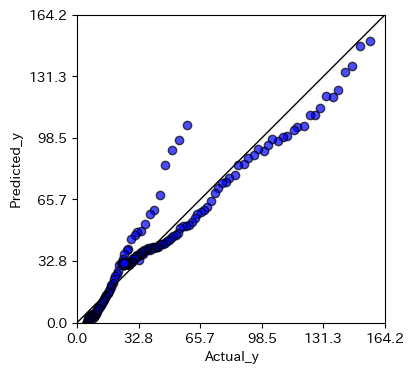

In [48]:
result_kou_3_deri = pls_regression_cv(
    X = spectra_kou_3_deri, 
    y = y_kou_3, 
    n_splits=5,
    n_components=2,
    random_state=117
    )

evaluate_and_plot(y_kou_3, result_kou_3_deri["oof_pred"])

In [29]:
len(y)

1210

In [49]:
len(result_shin_deri["oof_pred"]), len(result_kou_1_deri["oof_pred"]), len(result_kou_2_deri["oof_pred"]), len(result_kou_3_deri["oof_pred"])

(399, 274, 158, 197)

In [55]:
valid_result = pd.DataFrame()
valid_result["actual"] = y
valid_result["pred"] = np.nan

valid_result.loc[shin_idx, "pred"] = result_shin_deri["oof_pred"]
valid_result.loc[kou_1_idx, "pred"] = result_kou_1_deri["oof_pred"]
valid_result.loc[kou_2_idx, "pred"] = result_kou_2_deri["oof_pred"]
valid_result.loc[kou_3_idx, "pred"] = result_kou_3_deri["oof_pred"]

valid_result = valid_result.dropna()

R2: 0.9637075046432058
RMSE: 7.7517886626706
MAE: 5.661647289721482


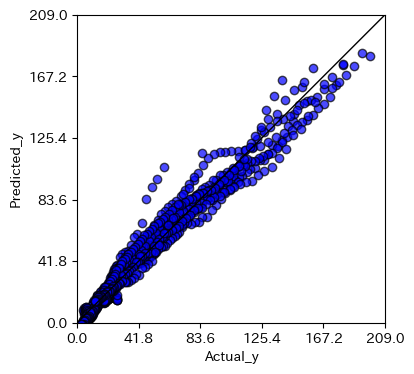

In [57]:
evaluate_and_plot(valid_result["actual"], valid_result["pred"])

# 再学習

In [58]:
# =========================
# 6. 最終モデル
# =========================
#scaler = StandardScaler(with_std=False)
#X_scaled = scaler.fit_transform(spectra_deri)

pls_shin = PLSRegression(n_components=2)
pls_shin.fit(spectra_shin_deri, y_shin)

pls_kou_1 = PLSRegression(n_components=2)
pls_kou_1.fit(spectra_kou_1_deri, y_kou_1)

pls_kou_2 = PLSRegression(n_components=2)
pls_kou_2.fit(spectra_kou_2_deri, y_kou_2)

pls_kou_3 = PLSRegression(n_components=2)
pls_kou_3.fit(spectra_kou_3_deri, y_kou_3)


,"n_components n_components: int, default=2Number of components to keep. Should be in `[1, n_features]`.",2
,"scale scale: bool, default=TrueWhether to scale `X` and `y`.",True
,"max_iter max_iter: int, default=500The maximum number of iterations of the power method when`algorithm='nipals'`. Ignored otherwise.",500
,"tol tol: float, default=1e-06The tolerance used as convergence criteria in the power method: thealgorithm stops whenever the squared norm of `u_i - u_{i-1}` is lessthan `tol`, where `u` corresponds to the left singular vector.",1e-06
,"copy copy: bool, default=TrueWhether to copy `X` and `y` in :term:`fit` before applying centering,and potentially scaling. If `False`, these operations will be doneinplace, modifying both arrays.",True


R2: 0.9764869184291189
RMSE: 7.312415602881094
MAE: 5.68184518579238


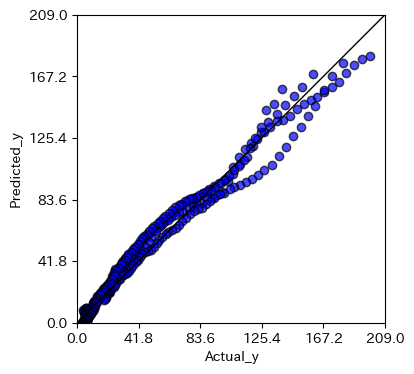

R2: 0.9647633067571588
RMSE: 7.605072347121552
MAE: 5.672544073118117


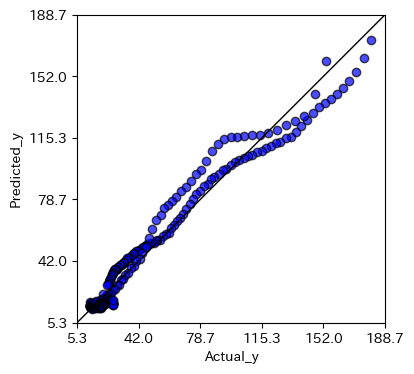

R2: 0.9346127202526967
RMSE: 6.192433402293967
MAE: 4.065051174792303


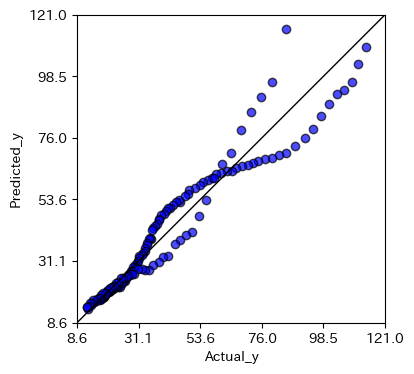

R2: 0.9352544257132861
RMSE: 8.948163102866625
MAE: 6.293711586189865


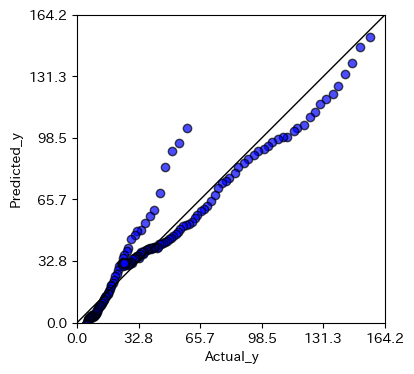

In [59]:
# 確認
train_pred_shin = pls_shin.predict(spectra_shin_deri).ravel()
evaluate_and_plot(y_shin, train_pred_shin)

train_pred_kou_1 = pls_kou_1.predict(spectra_kou_1_deri).ravel()
evaluate_and_plot(y_kou_1, train_pred_kou_1)

train_pred_kou_2 = pls_kou_2.predict(spectra_kou_2_deri).ravel()
evaluate_and_plot(y_kou_2, train_pred_kou_2)

train_pred_kou_3 = pls_kou_3.predict(spectra_kou_3_deri).ravel()
evaluate_and_plot(y_kou_3, train_pred_kou_3)

# テスト予測

In [60]:
# =========================
# 7. テスト予測
# =========================
test_shin = [
    'スギ',
]
test_kou_1 = [
    'クスノキ', 
    'ヤマザクラ'
]

test_kou_2 = [
    'ケヤキ',  
    'タモ', 
]

test_kou_3 = [
    'チーク', 
]

test_shin = test.loc[test["樹種"].isin(test_shin)]
test_kou_1 = test.loc[test["樹種"].isin(test_kou_1)]
test_kou_2 = test.loc[test["樹種"].isin(test_kou_2)]
test_kou_3 = test.loc[test["樹種"].isin(test_kou_3)]

In [61]:
shin_id_test = test_shin.iloc[:, 0]
kou_1_id_test = test_kou_1.iloc[:, 0]
kou_2_id_test = test_kou_2.iloc[:, 0]
kou_3_id_test = test_kou_3.iloc[:, 0]

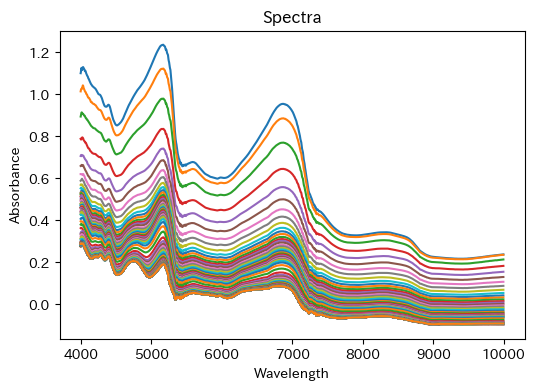

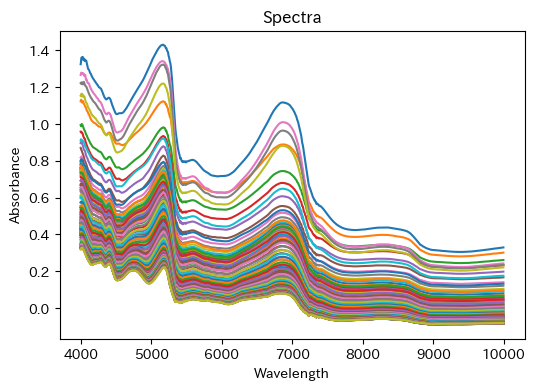

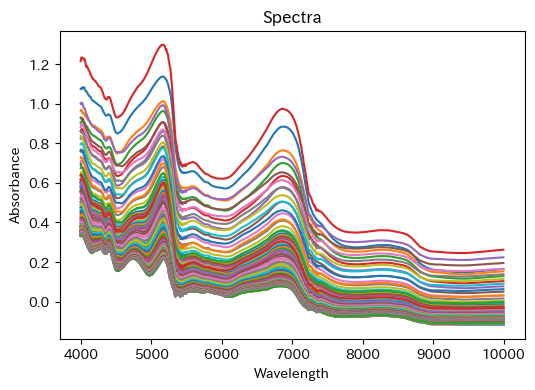

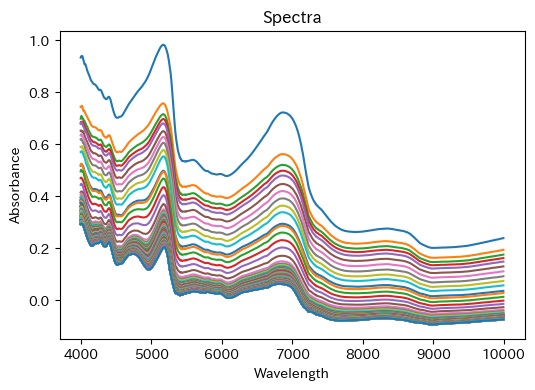

In [62]:
spectra_test_shin = test_shin.iloc[:, 3:]
spectra_test_shin.columns = spectra_test_shin.columns.astype(float)
spectra_test_shin = spectra_test_shin[spectra_shin.columns]

spectra_test_kou_1 = test_kou_1.iloc[:, 3:]
spectra_test_kou_1.columns = spectra_test_kou_1.columns.astype(float)
spectra_test_kou_1 = spectra_test_kou_1[spectra_kou_1.columns]

spectra_test_kou_2 = test_kou_2.iloc[:, 3:]
spectra_test_kou_2.columns = spectra_test_kou_2.columns.astype(float)
spectra_test_kou_2 = spectra_test_kou_2[spectra_kou_2.columns]

spectra_test_kou_3 = test_kou_3.iloc[:, 3:]
spectra_test_kou_3.columns = spectra_test_kou_3.columns.astype(float)
spectra_test_kou_3 = spectra_test_kou_3[spectra_kou_3.columns]

plot_spectra(spectra_test_shin.columns, spectra_test_shin)
plot_spectra(spectra_test_kou_1.columns, spectra_test_kou_1)
plot_spectra(spectra_test_kou_2.columns, spectra_test_kou_2)
plot_spectra(spectra_test_kou_3.columns, spectra_test_kou_3)

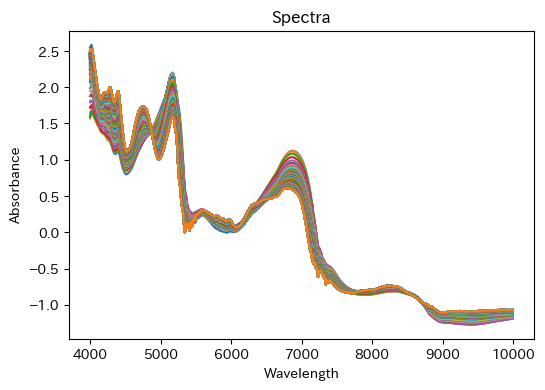

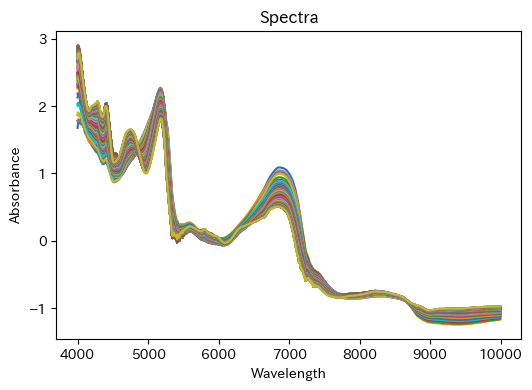

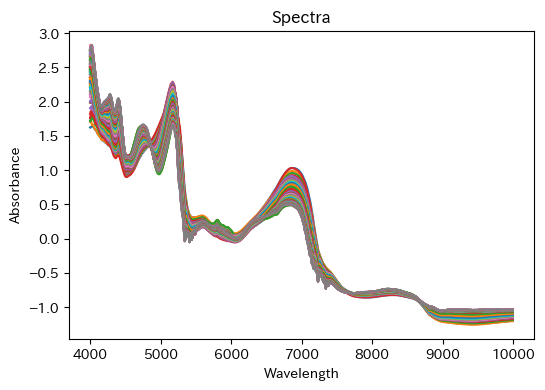

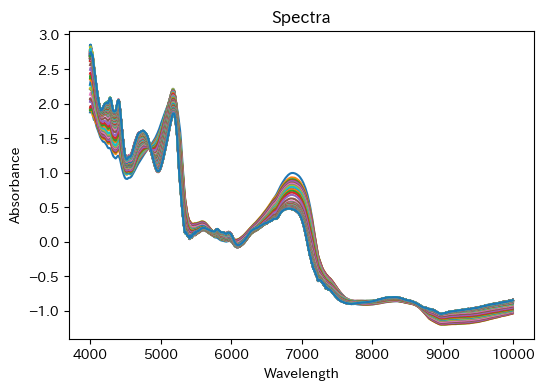

In [63]:
# trainの平均スペクトルを用いて_SNVを適用
spectra_test_shin_snv = snv_transform(spectra_test_shin)
spectra_test_kou_1_snv = snv_transform(spectra_test_kou_1)
spectra_test_kou_2_snv = snv_transform(spectra_test_kou_2)
spectra_test_kou_3_snv = snv_transform(spectra_test_kou_3)

plot_spectra(spectra_test_shin_snv.columns, spectra_test_shin_snv)
plot_spectra(spectra_test_kou_1_snv.columns, spectra_test_kou_1_snv)
plot_spectra(spectra_test_kou_2_snv.columns, spectra_test_kou_2_snv)
plot_spectra(spectra_test_kou_3_snv.columns, spectra_test_kou_3_snv)

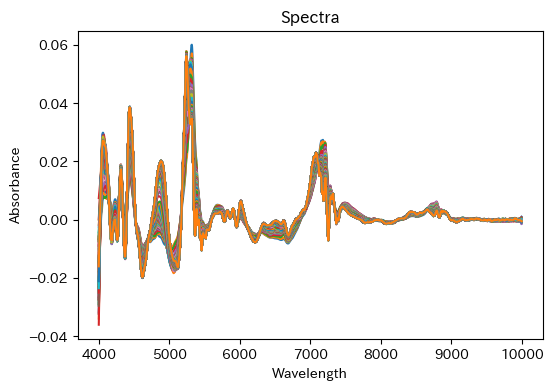

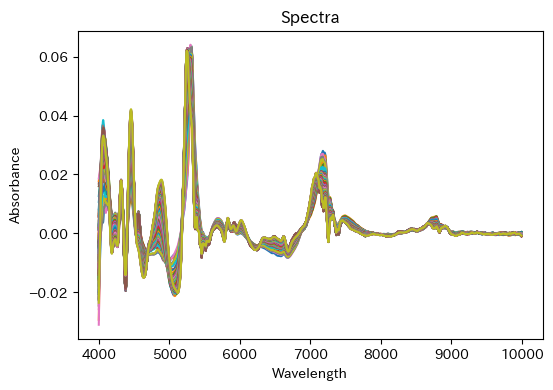

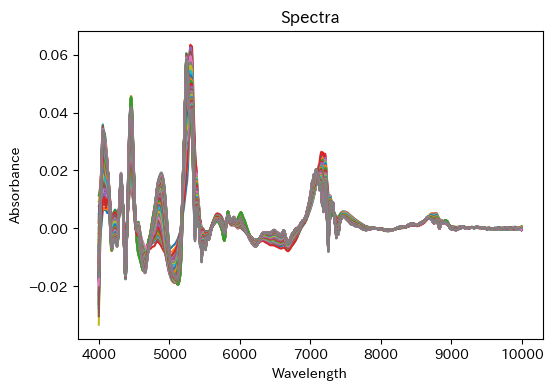

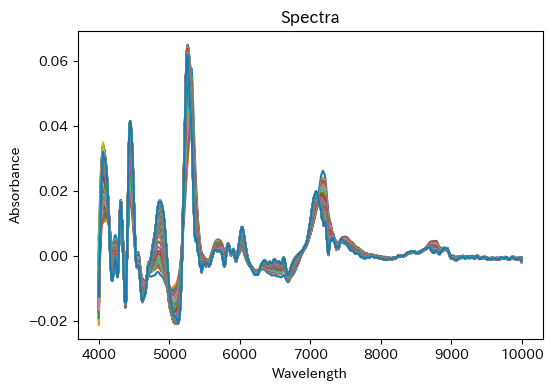

In [64]:
spectra_test_shin_deri = derivative(spectra_test_shin_snv, order=1, window_length=15, polyorder=2)
plot_spectra(spectra_test_shin_deri.columns, spectra_test_shin_deri)

spectra_test_kou_1_deri = derivative(spectra_test_kou_1_snv, order=1, window_length=15, polyorder=2)
plot_spectra(spectra_test_kou_1_deri.columns, spectra_test_kou_1_deri)

spectra_test_kou_2_deri = derivative(spectra_test_kou_2_snv, order=1, window_length=15, polyorder=2)
plot_spectra(spectra_test_kou_2_deri.columns, spectra_test_kou_2_deri)

spectra_test_kou_3_deri = derivative(spectra_test_kou_3_snv, order=1, window_length=15, polyorder=2)
plot_spectra(spectra_test_kou_3_deri.columns, spectra_test_kou_3_deri)

In [65]:
#X_test_scaled = scaler.transform(spectra_test_deri)
y_pred_shin = pls_shin.predict(spectra_test_shin_deri).ravel()
y_pred_kou_1 = pls_kou_1.predict(spectra_test_kou_1_deri).ravel()
y_pred_kou_2 = pls_kou_2.predict(spectra_test_kou_2_deri).ravel()
y_pred_kou_3 = pls_kou_3.predict(spectra_test_kou_3_deri).ravel()

#print(y_pred)

In [67]:
submit = pd.read_csv(r"C:\Users\takit\Documents\data\signate_NIR\data\sample_submit.csv", encoding="cp932", header=None)

In [68]:
# それぞれSeries化（IDをindexに）
map_shin = pd.Series(y_pred_shin, index=shin_id_test)
map_kou_1 = pd.Series(y_pred_kou_1, index=kou_1_id_test)
map_kou_2 = pd.Series(y_pred_kou_2, index=kou_2_id_test)
map_kou_3 = pd.Series(y_pred_kou_3, index=kou_3_id_test)

# 結合（shinとkouを統合）
map_all = pd.concat([map_shin, map_kou_1, map_kou_2, map_kou_3])

# 一括代入
submit[1] = submit.iloc[:, 0].map(map_all)

In [69]:
submit.loc[submit[1] < 0, 1] = 1
submit.head()

,0,1
0,95,177.059231
1,96,163.324328
2,97,155.082800
3,98,147.830024
4,99,139.086906


In [70]:
submit.to_csv(r"C:\Users\takit\Documents\data\signate_NIR\submission\submission_260426_2.csv", index=False, header=False)